Developing a machine learning model to predict customer churn
for a telecommunications company. The company wants to identify which customers are likely to
leave (churn) and target them with retention offers. Your goal is to create a machine learning
model that accurately predicts customer churn based on historical customer data.

# Step 1: Understand the Dataset and Load the Data

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

## Load the Dataset

In [ ]:
train_df = pd.read_csv("Training_data.csv")
test_df = pd.read_csv("Testing_data.csv")

## View First 5 rows

In [ ]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


## Check Dataset Shape

In [ ]:
train_df.shape

(5634, 21)

In [ ]:
test_df.shape

(1409, 21)

## Check Column Names

In [ ]:
train_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Check Data Types

In [ ]:
train_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## Basic Statistical Summary

In [ ]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


For Categorical columns

In [ ]:
train_df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,5634,5465,5634,5634,5634,5634,5634,5465,5634,5634,5634,5634,5634,5634,5634,5634,5353,5634
unique,5634,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,5040,2
top,3402-XRIUO,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,2744,2890,3960,5081,2701,2486,2720,2459,2485,2782,2244,2232,3094,3350,1892,9,4130


# Step 2: Exploratory Data Analysis (EDA)

## Check Missing Values

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
missing_percentage = (train_df.isnull().sum()/len(train_df))*100

missing_percentage.sort_values(ascending = False)

,0
MonthlyCharges,6.993255
TotalCharges,4.987575
OnlineSecurity,2.999645
gender,2.999645
customerID,0.000000
Dependents,0.000000
Partner,0.000000
SeniorCitizen,0.000000
tenure,0.000000
InternetService,0.000000


## Check Blank Spaces in TotalCharges

In [ ]:
(train_df['TotalCharges'] == '').sum()

np.int64(0)

In [ ]:
train_df['TotalCharges'] = pd.to_numeric(
    train_df['TotalCharges'],
    errors='coerce'
)

In [ ]:
train_df['TotalCharges'].dtype

dtype('float64')

## Separate Numerical and Categorical Columns

In [ ]:
numerical_cols = train_df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = train_df.select_dtypes(
    include=['object']
).columns

In [ ]:
print('Numerical Columns:')
print(numerical_cols)

print("/nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
/nCategorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


## Target Variable Distribution

In [ ]:
# Check class distribution:
train_df['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


In [ ]:
# Percentage:
train_df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.304934
Yes,26.695066


## Visualize Churn Distribution

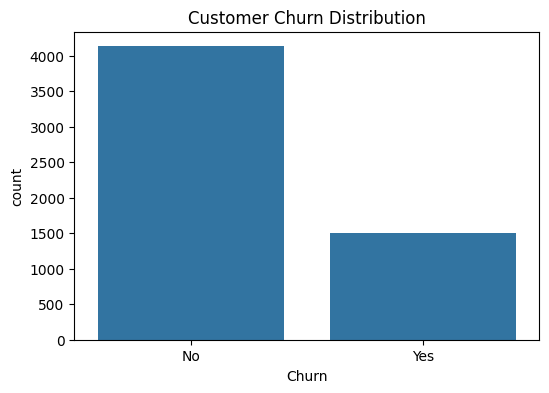

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=train_df
)

plt.title("Customer Churn Distribution")
plt.show()

## Numerical Feature Distribution

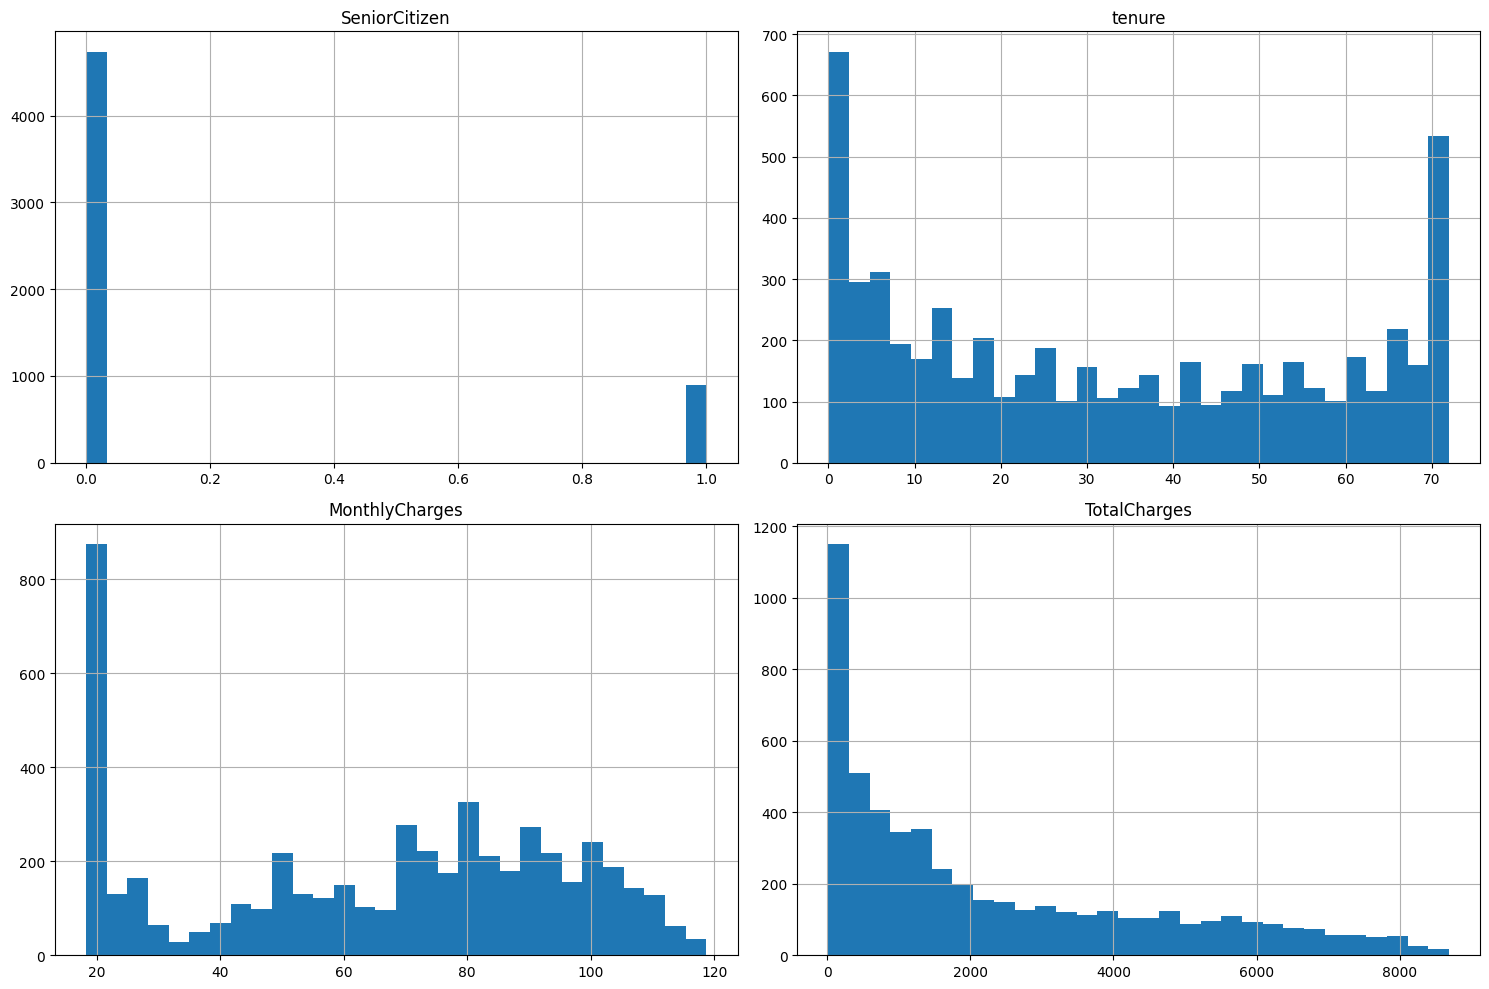

In [ ]:
train_df[numerical_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

## Boxplots for Outlier Detection

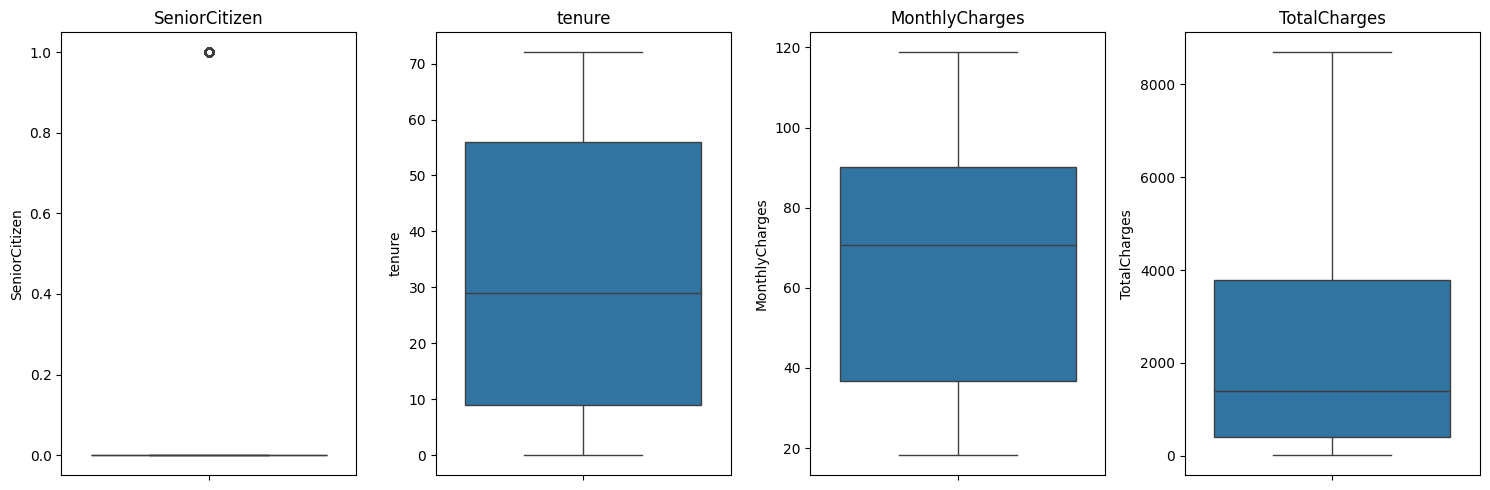

In [ ]:
plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols, 1):

  plt.subplot(1, len(numerical_cols), i)

  sns.boxplot(
      y=train_df[col]
  )

  plt.title(col)

plt.tight_layout()
plt.show()

## Categorical Feature Analysis

In [ ]:
# Countplots for Categorical Features
important_cat_cols = [
    'Contract',
    'PaymentMethod',
    'gender',
    'PaperlessBilling'
]

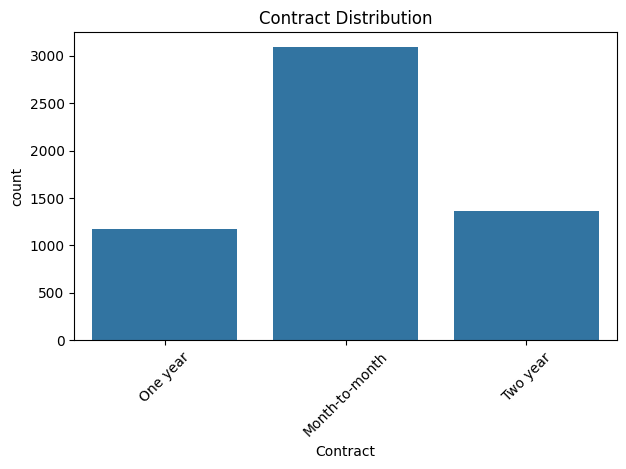

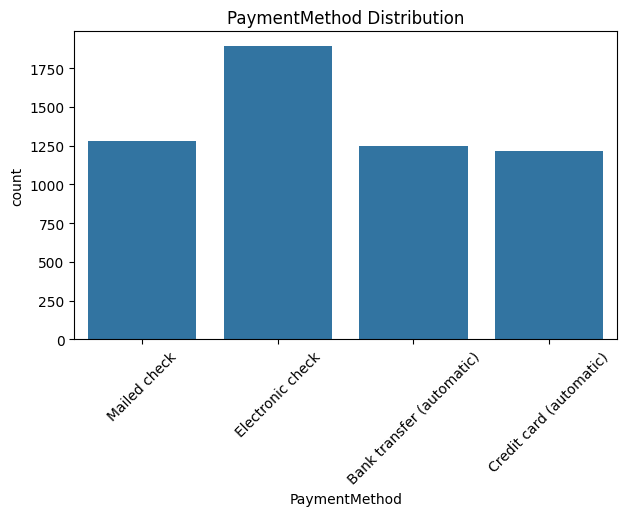

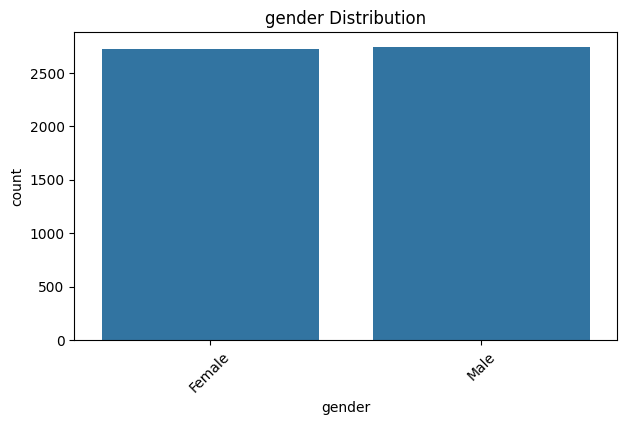

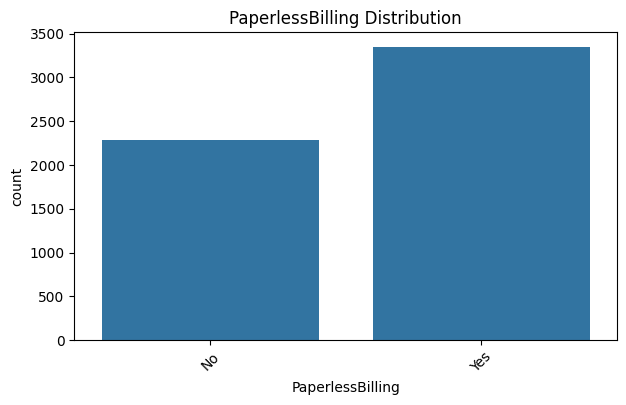

In [ ]:
for col in important_cat_cols:

  plt.figure(figsize=(7,4))

  sns.countplot(
      x=col,
      data=train_df
  )

  plt.xticks(rotation=45)

  plt.title(f"{col} Distribution")

  plt.show()

## Relationship Between Features and Churn

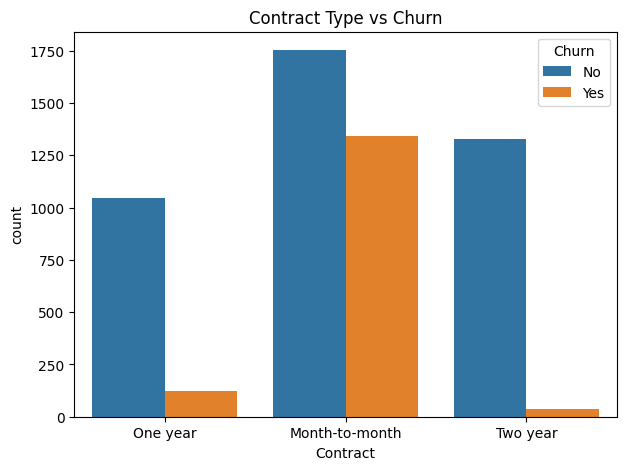

In [ ]:
# Churn vs Contract
plt.figure(figsize=(7,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=train_df
)

plt.title("Contract Type vs Churn")

plt.show()

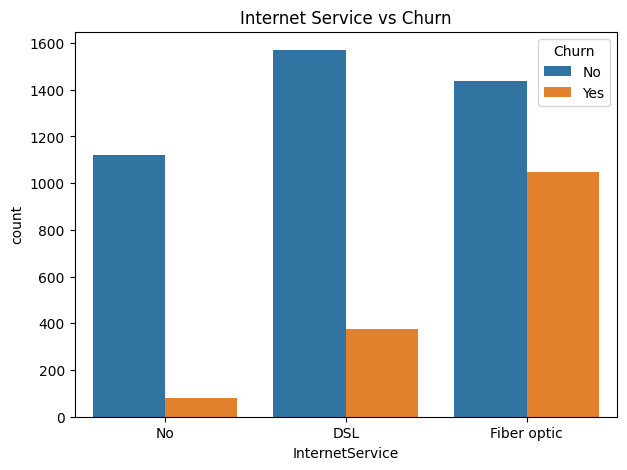

In [ ]:
# Churn vs Internet Service
plt.figure(figsize=(7,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=train_df
)

plt.title("Internet Service vs Churn")

plt.show()

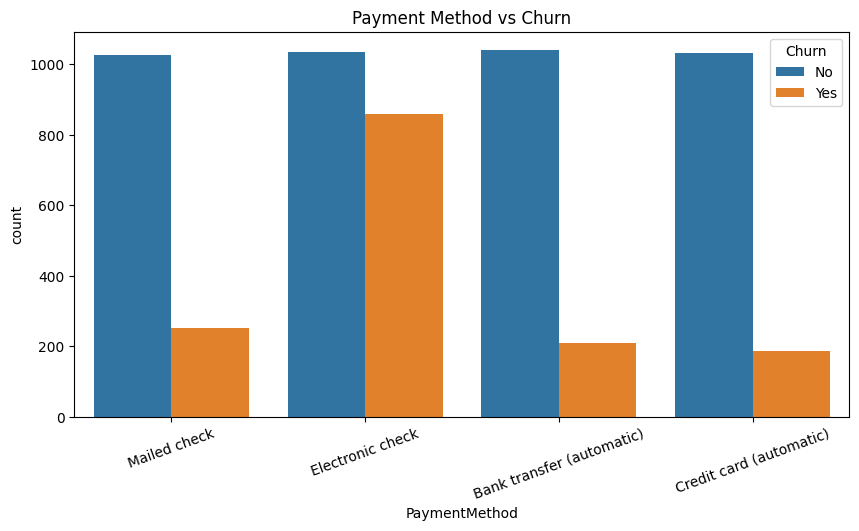

In [ ]:
# Churn vs Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=train_df
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

## Numerical Features vs Churn

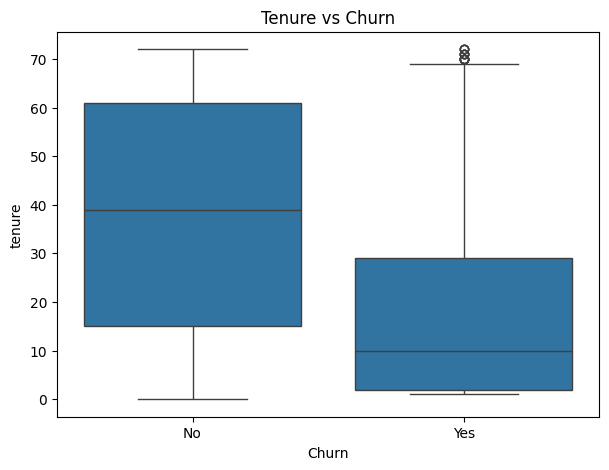

In [ ]:
# Tenure vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=train_df
)

plt.title("Tenure vs Churn")

plt.show()

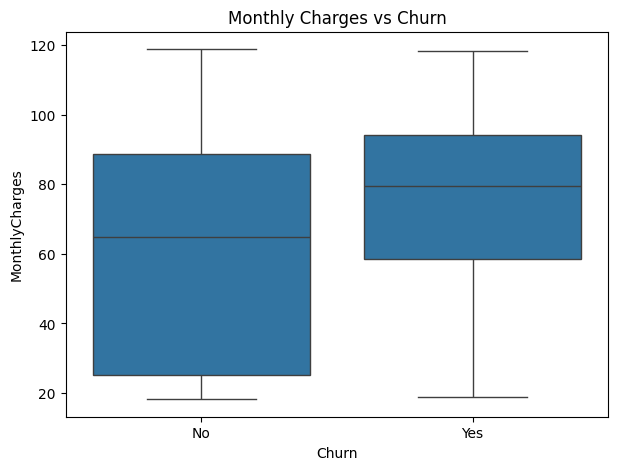

In [ ]:
# Monthly Charges vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=train_df
)

plt.title("Monthly Charges vs Churn")

plt.show()

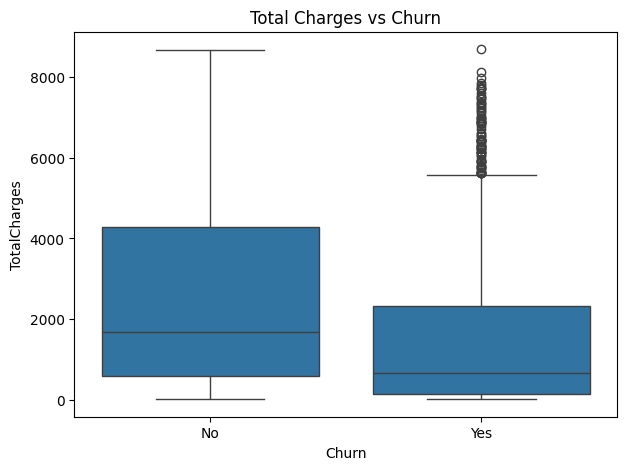

In [ ]:
# Total Charges vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=train_df
)

plt.title("Total Charges vs Churn")

plt.show()

## Correlation Analysis

In [ ]:
# encode chirn temporarily
train_df['Churn_numeric'] = train_df['Churn'].map({
    'Yes':1,
    'No':0
})

In [ ]:
# Correlation Matrix
correlation_matrix = train_df.corr(
    numeric_only=True
)

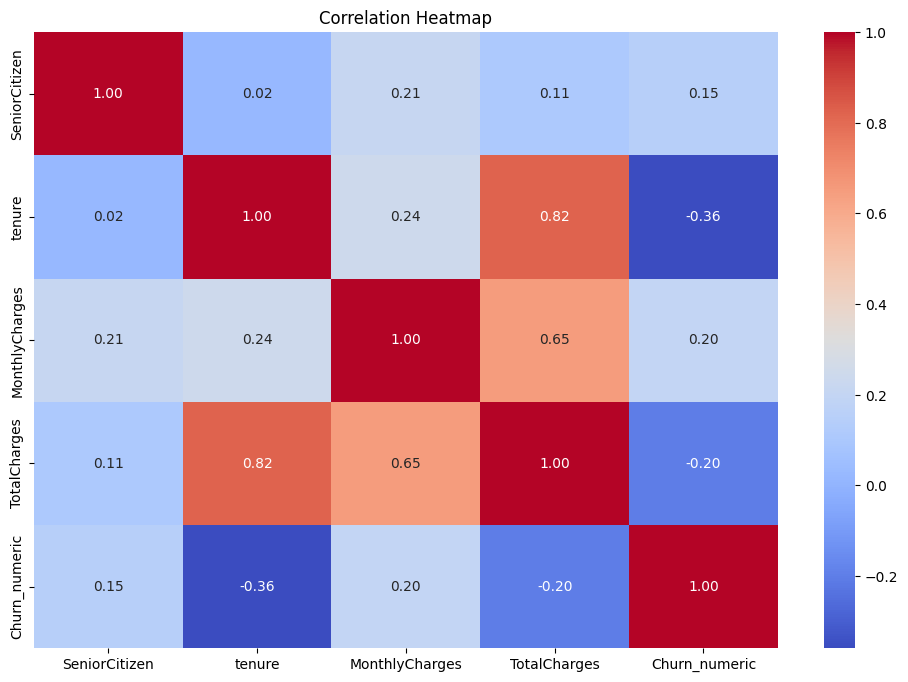

In [ ]:
# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

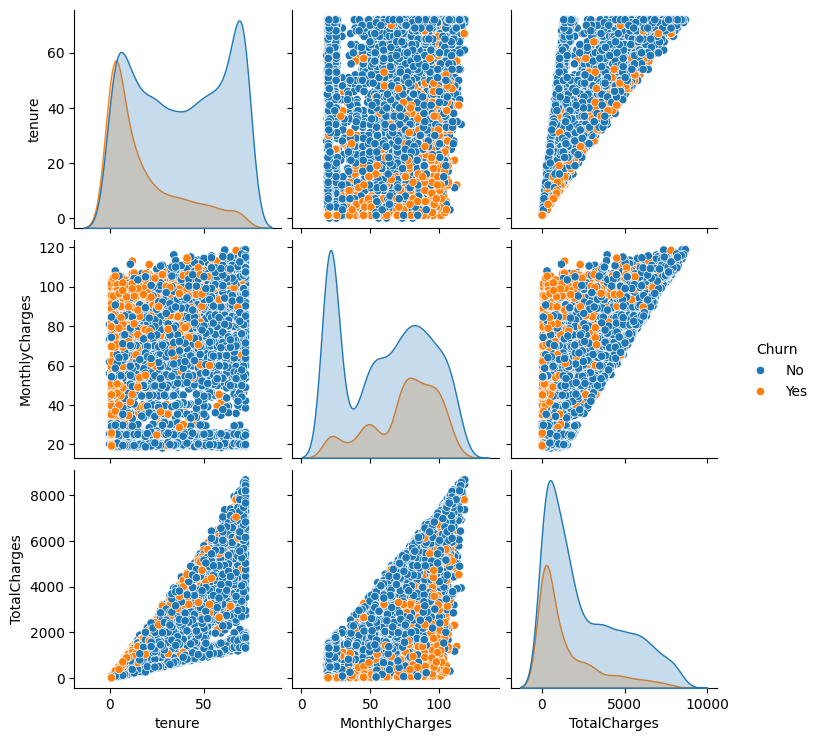

In [ ]:
# Pairplot
sns.pairplot(
    train_df[
        [
            'tenure',
            'MonthlyCharges',
            'TotalCharges',
            'Churn'
        ]
    ],
    hue='Churn'
)

plt.show()

# Step 3: Data Preprocessing

## Create a Copy of Dataset

In [ ]:
df = train_df.copy()

## Remove Unnecessary Columns

In [ ]:
df.drop('customerID', axis=1, inplace=True)

## Handle Missing Values

In [ ]:
df.isnull().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [ ]:
# Fill Missing Values
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

/tmp/ipykernel_6448/3326307926.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


In [ ]:
# Verify Missing Values
df.isnull().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


## Encode Target Variable

In [ ]:
# Encode Churn
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
# Verify
df['Churn'].head()

,Churn
0,0
1,0
2,0
3,0
4,0


## Identify Categorical Columns

In [ ]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns

numerical_cols = df.select_dtypes(
    exclude=['object']
).columns

In [ ]:
# View Columns
print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_numeric'],
      dtype='object')


## Handle Remaining Missing Values

In [ ]:
# Fill numerical missing values using median

df['MonthlyCharges'].fillna(
    df['MonthlyCharges'].median(),
    inplace=True
)

# Fill categorical missing values using mode

df['gender'].fillna(
    df['gender'].mode()[0],
    inplace=True
)

df['OnlineSecurity'].fillna(
    df['OnlineSecurity'].mode()[0],
    inplace=True
)

/tmp/ipykernel_6448/32989258.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyCharges'].fillna(
/tmp/ipykernel_6448/32989258.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: 

In [ ]:
# Verify Again
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Encode Categorical Variables

In [ ]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
# Check Encoded Dataset
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_numeric,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,35,20.75,700.45,0,0,False,False,False,True,...,True,False,True,False,True,False,False,False,False,True
1,0,28,35.75,961.40,0,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,0,56,98.60,5581.05,0,0,True,False,False,True,...,False,True,False,True,False,False,False,False,True,False
3,0,39,20.45,790.00,0,0,True,True,False,True,...,True,False,True,False,False,True,True,False,False,False
4,0,43,51.25,2151.60,0,0,False,True,True,False,...,False,True,False,False,True,False,True,False,False,False


In [ ]:
# Compare Shapes
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (5634, 21)
Encoded Shape: (5634, 32)


## Separate Features and Target

In [ ]:
X = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

In [ ]:
# Verify Shapes
print(X.shape)
print(y.shape)

(5634, 31)
(5634,)


## Train-Test Split

In [ ]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Verify Split
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4507, 31)
(1127, 31)
(4507,)
(1127,)


## Feature Scaling

In [ ]:
# Initialize Scaler
scaler = StandardScaler()

In [ ]:
# Scale Features
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Convert Back to DataFrame

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

## Outlier Handling

In [ ]:
# Detect Outliers Using IQR
Q1 = df['MonthlyCharges'].quantile(0.25)

Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['MonthlyCharges'] < lower_bound) |
    (df['MonthlyCharges'] > upper_bound)
]

print(outliers.shape)

(0, 21)


# Step 4: Feature Engineering

In [ ]:
# Create a Working Copy
X_train_fe = X_train.copy()

X_test_fe = X_test.copy()

In [ ]:
# Customer Lifetime Value Feature
X_train_fe['CLV'] = (
    X_train_fe['tenure'] *
    X_train_fe['MonthlyCharges']
)

X_test_fe['CLV'] = (
    X_test_fe['tenure'] *
    X_test_fe['MonthlyCharges']
)

In [ ]:
# Average Monthly Spend Feature
X_train_fe['AverageSpend'] = (
    X_train_fe['TotalCharges'] /
    (X_train_fe['tenure'] + 1)
)

X_test_fe['AverageSpend'] = (
    X_test_fe['TotalCharges'] /
    (X_test_fe['tenure'] + 1)
)

## Service Count Feature

In [ ]:
# Identify Service Columns
service_cols = [
    col for col in X_train_fe.columns
    if (
        'Online' in col or
        'Streaming' in col or
        'TechSupport' in col or
        'DeviceProtection' in col or
        'PhoneService' in col
    )
]

In [ ]:
# View Service Columns
print(service_cols)

['PhoneService_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [ ]:
# Create Total Services Feature
X_train_fe['TotalServices'] = X_train_fe[
    service_cols
].sum(axis=1)

X_test_fe['TotalServices'] = X_test_fe[
    service_cols
].sum(axis=1)

## Contract Risk Feature

In [ ]:
X_train_fe['IsMonthlyContract'] = ~(
    X_train_fe['Contract_One year'] |
    X_train_fe['Contract_Two year']
)

X_test_fe['IsMonthlyContract'] = ~(
    X_test_fe['Contract_One year'] |
    X_test_fe['Contract_Two year']
)

## Tenure Group Feature

In [ ]:
# Create Tenure Categories
X_train_fe['TenureGroup'] = pd.cut(
    X_train_fe['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)

X_test_fe['TenureGroup'] = pd.cut(
    X_test_fe['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)

In [ ]:
X_train_fe['TenureGroup'] = (
    X_train_fe['TenureGroup']
    .astype(float) # Convert to float to allow NaN values to be treated as floats
    .fillna(0) # Fill NaN with 0 (assuming tenure=0 should be in the first group)
    .astype(int)
)

X_test_fe['TenureGroup'] = (
    X_test_fe['TenureGroup']
    .astype(float)
    .fillna(0)
    .astype(int)
)

## High Charges Indicator

In [ ]:
# premium/high-cost customer indicator
# create feature
monthly_charge_threshold = (
    X_train_fe['MonthlyCharges']
    .median()
)

X_train_fe['HighMonthlyCharges'] = (
    X_train_fe['MonthlyCharges']
    > monthly_charge_threshold
).astype(int)

X_test_fe['HighMonthlyCharges'] = (
    X_test_fe['MonthlyCharges']
    > monthly_charge_threshold
).astype(int)

## Senior Citizen + High Charges Interaction

In [ ]:
# Create Feature
X_train_fe['SeniorHighCharges'] = (
    X_train_fe['SeniorCitizen'] *
    X_train_fe['HighMonthlyCharges']
)

X_test_fe['SeniorHighCharges'] = (
    X_test_fe['SeniorCitizen'] *
    X_test_fe['HighMonthlyCharges']
)

## Check New Feature Shapes

In [ ]:
print(X_train.shape)

print(X_train_fe.shape)

(4507, 31)
(4507, 38)


## Feature Importance Using Random Forest

In [ ]:
# Train Temporary Model
rf_temp = RandomForestClassifier(
    random_state=42
)

rf_temp.fit(
    X_train_fe,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
# Extract Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Importance': rf_temp.feature_importances_
})

In [ ]:
# Sort Importance
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [ ]:
# View Top Features
feature_importance.head(15)

,Feature,Importance
4,Churn_numeric,0.625155
1,tenure,0.052924
34,IsMonthlyContract,0.039538
31,CLV,0.032978
11,InternetService_Fiber optic,0.027889
2,MonthlyCharges,0.027699
3,TotalCharges,0.026532
32,AverageSpend,0.024590
35,TenureGroup,0.021551
33,TotalServices,0.020528


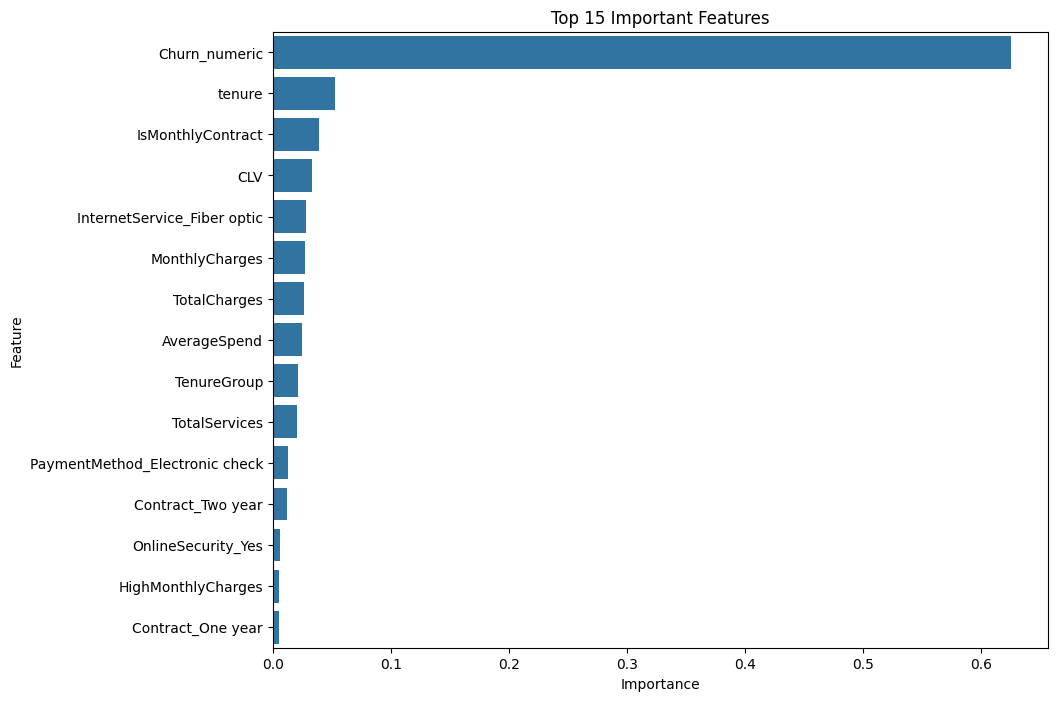

In [ ]:
# Visualize Feature Importance
plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

## Remove Low-Importance Features

In [ ]:
# Sometimes:

# irrelevant features add noise
# increase overfitting

# You can remove low-importance columns later.

# But for now:

# keep all features

# because tree models handle irrelevant features reasonably well.

## Correlation Between New Features

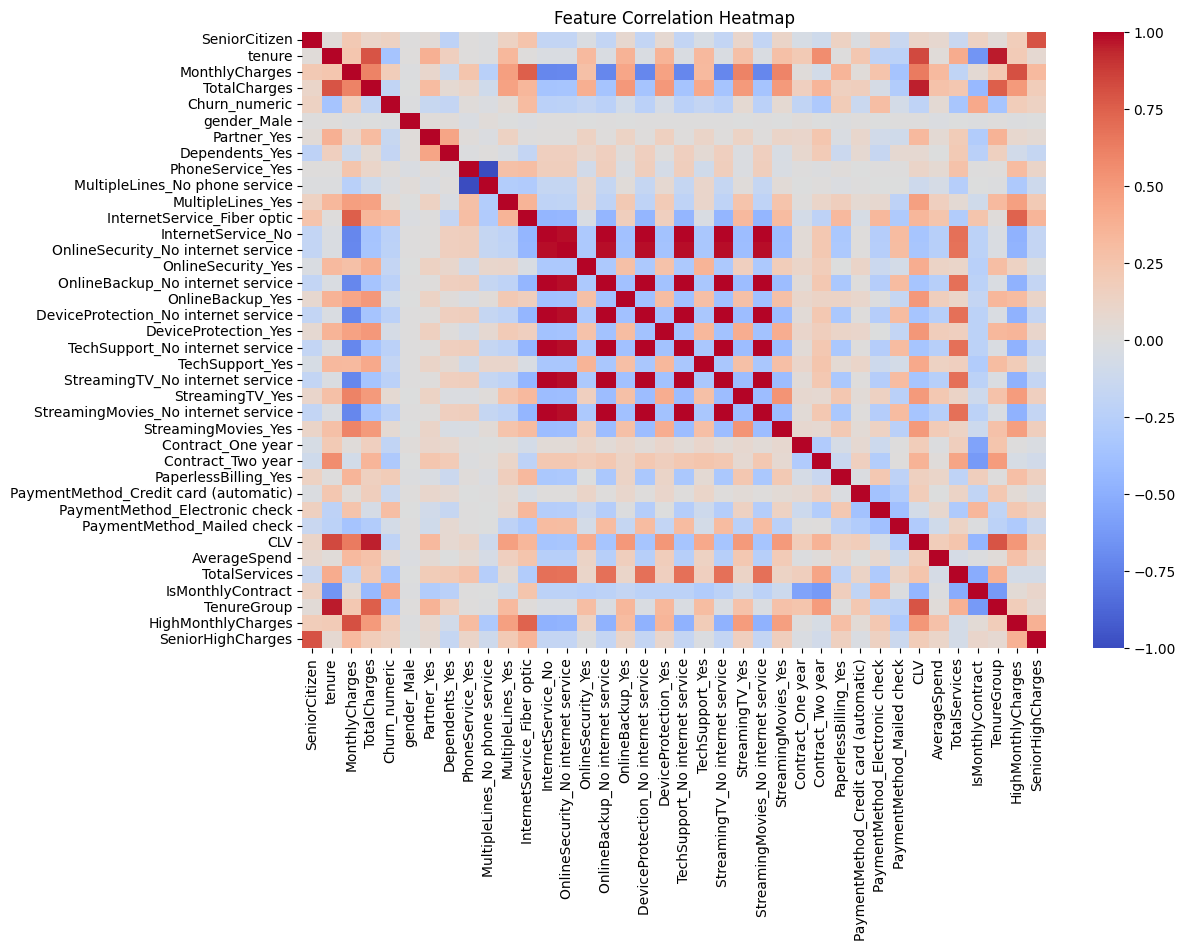

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X_train_fe.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Step 5: Model Development

## Scale Feature Engineered Dataset

In [ ]:
# Scale New Dataset
scaler = StandardScaler()

X_train_fe_scaled = scaler.fit_transform(X_train_fe)

X_test_fe_scaled = scaler.transform(X_test_fe)

## Logistic Regression

In [ ]:
# Create Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    try:
        y_prob = model.predict_proba(X_test)[:,1]
    except:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Print results
    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1 Score:", f1)

    # ROC-AUC
    if y_prob is not None:

        auc = roc_auc_score(y_test, y_prob)

        print("ROC-AUC:", auc)

    # Confusion Matrix
    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

## Linear Regression

In [ ]:
# Train Model
linear_model = LinearRegression()

In [ ]:
# Train
linear_model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [ ]:
# Predictions
linear_pred = linear_model.predict(
    X_test_scaled
)

In [ ]:
# Thresholding
linear_pred_binary = (
    linear_pred >= 0.5
).astype(int)

In [ ]:
# Evaluate
print(
    classification_report(
        y_test,
        linear_pred_binary
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Logistic Regression

In [ ]:
# Initialize Model
log_model = LogisticRegression(
    max_iter=1000
)

In [ ]:
# Evaluate
log_results = evaluate_model(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## K-Nearest Neighbors (KNN)

In [ ]:
# Initialize Model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [ ]:
# Evaluate
knn_results = evaluate_model(
    knn_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 0.9716060337178349
Precision: 0.9926739926739927
Recall: 0.9003322259136213
F1 Score: 0.9442508710801394
ROC-AUC: 0.9864656150201508

Confusion Matrix
[[824   2]
 [ 30 271]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       826
           1       0.99      0.90      0.94       301

    accuracy                           0.97      1127
   macro avg       0.98      0.95      0.96      1127
weighted avg       0.97      0.97      0.97      1127



## Naive Bayes

In [ ]:
# Initialize Model
nb_model = GaussianNB()

In [ ]:
# Evaluate
nb_results = evaluate_model(
    nb_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Support Vector Machine (SVM)

In [ ]:
# Initialize Model
svm_model = SVC(
    probability=True
)

In [ ]:
# Evaluate
svm_results = evaluate_model(
    svm_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Decision Tree

In [ ]:
# Initialize Model
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
# Evaluate
dt_results = evaluate_model(
    dt_model,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Compare Models

In [ ]:
# Create Results DataFrame
results_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM',
        'Decision Tree'
    ],

    'Accuracy': [
        log_results['Accuracy'],
        knn_results['Accuracy'],
        nb_results['Accuracy'],
        svm_results['Accuracy'],
        dt_results['Accuracy']
    ],

    'Precision': [
        log_results['Precision'],
        knn_results['Precision'],
        nb_results['Precision'],
        svm_results['Precision'],
        dt_results['Precision']
    ],

    'Recall': [
        log_results['Recall'],
        knn_results['Recall'],
        nb_results['Recall'],
        svm_results['Recall'],
        dt_results['Recall']
    ],

    'F1 Score': [
        log_results['F1'],
        knn_results['F1'],
        nb_results['F1'],
        svm_results['F1'],
        dt_results['F1']
    ]
})

In [ ]:
# Display Results
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,KNN,0.971606,0.992674,0.900332,0.944251
2,Naive Bayes,1.000000,1.000000,1.000000,1.000000
3,SVM,1.000000,1.000000,1.000000,1.000000
4,Decision Tree,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Sort Best Models
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
2,Naive Bayes,1.000000,1.000000,1.000000,1.000000
3,SVM,1.000000,1.000000,1.000000,1.000000
4,Decision Tree,1.000000,1.000000,1.000000,1.000000
1,KNN,0.971606,0.992674,0.900332,0.944251


## Visualize Model Performance

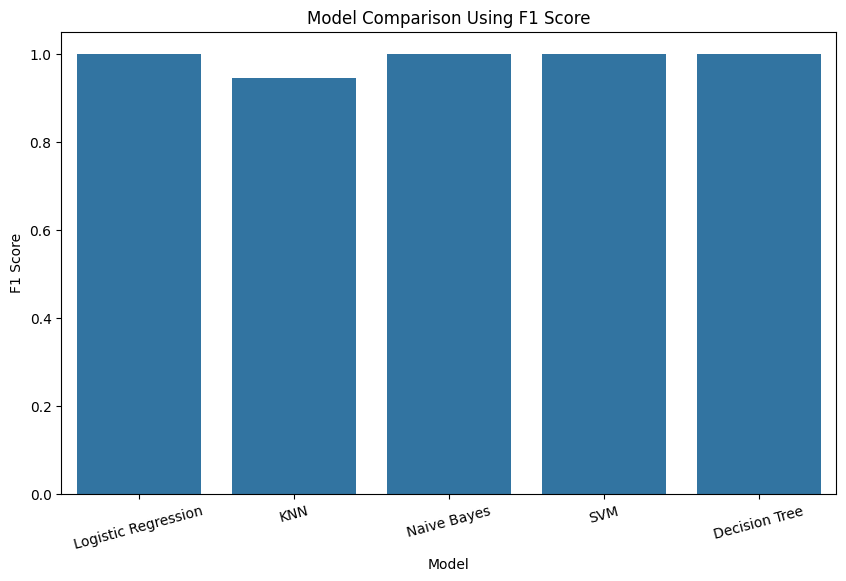

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.xticks(rotation=15)

plt.title("Model Comparison Using F1 Score")

plt.show()

# Step 6: Hyperparameter Tuning

## Hyperparameter Tuning for KNN

In [ ]:
# Create Parameter Grid
knn_params = {
    'n_neighbors': [3,5,7,9,11,13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [ ]:
# Create GridSearchCV
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [ ]:
# Train GridSearch
knn_grid.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [ ]:
# Best Parameters
print(knn_grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}


In [ ]:
# Best Score
print(knn_grid.best_score_)

0.962079050617372


In [ ]:
# Best KNN Model
best_knn = knn_grid.best_estimator_

In [ ]:
# Evaluate Tuned KNN
knn_tuned_results = evaluate_model(
    best_knn,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 0.976929902395741
Precision: 1.0
Recall: 0.9136212624584718
F1 Score: 0.9548611111111112
ROC-AUC: 0.9885048225044846

Confusion Matrix
[[826   0]
 [ 26 275]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       826
           1       1.00      0.91      0.95       301

    accuracy                           0.98      1127
   macro avg       0.98      0.96      0.97      1127
weighted avg       0.98      0.98      0.98      1127



## Hyperparameter Tuning for SVM

In [ ]:
# Create Parameter Grid
svm_params = {

    'C': [0.1, 1, 10],

    'kernel': ['linear', 'rbf'],

    'gamma': ['scale', 'auto']
}

In [ ]:
# Create GridSearch
svm_grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=svm_params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

In [ ]:
# Train
svm_grid.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [ ]:
# Best Parameters
print(svm_grid.best_params_)

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
# Best SVM Model
best_svm = svm_grid.best_estimator_

In [ ]:
# Evaluate Tuned SVM
svm_tuned_results = evaluate_model(
    best_svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Hyperparameter Tuning for Decision Tree

In [ ]:
# Parameter Grid
dt_params = {

    'max_depth': [3,5,7,10,None],

    'min_samples_split': [2,5,10],

    'min_samples_leaf': [1,2,4],

    'criterion': ['gini', 'entropy']
}

In [ ]:
# Create GridSearch
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [ ]:
# Train
dt_grid.fit(
    X_train_fe,
    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [ ]:
# Best Parameters
print(dt_grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Best Model
best_dt = dt_grid.best_estimator_

In [ ]:
# Evaluate Tuned Decision Tree
dt_tuned_results = evaluate_model(
    best_dt,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Logistic Regression Tuning

In [ ]:
# Parameter Grid
log_params = {

    'C': [0.01, 0.1, 1, 10],

    'solver': ['liblinear', 'lbfgs']
}

In [ ]:
# Create GridSearch
log_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000
    ),
    param_grid=log_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [ ]:
# Train
log_grid.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [ ]:
# Best Parameters
print(log_grid.best_params_)

{'C': 0.01, 'solver': 'liblinear'}


In [ ]:
# Best Model
best_log = log_grid.best_estimator_

In [ ]:
# Evaluate Tuned Logistic Regression
log_tuned_results = evaluate_model(
    best_log,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix
[[826   0]
 [  0 301]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      1.00      1.00       301

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



## Compare Tuned Models

In [ ]:
# Create Results DataFrame
tuned_results_df = pd.DataFrame({

    'Model': [
        'Tuned Logistic Regression',
        'Tuned KNN',
        'Tuned SVM',
        'Tuned Decision Tree'
    ],

    'Accuracy': [
        log_tuned_results['Accuracy'],
        knn_tuned_results['Accuracy'],
        svm_tuned_results['Accuracy'],
        dt_tuned_results['Accuracy']
    ],

    'Precision': [
        log_tuned_results['Precision'],
        knn_tuned_results['Precision'],
        svm_tuned_results['Precision'],
        dt_tuned_results['Precision']
    ],

    'Recall': [
        log_tuned_results['Recall'],
        knn_tuned_results['Recall'],
        svm_tuned_results['Recall'],
        dt_tuned_results['Recall']
    ],

    'F1 Score': [
        log_tuned_results['F1'],
        knn_tuned_results['F1'],
        svm_tuned_results['F1'],
        dt_tuned_results['F1']
    ]
})

In [ ]:
# View Results
tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,1.00000,1.0,1.000000,1.000000
1,Tuned KNN,0.97693,1.0,0.913621,0.954861
2,Tuned SVM,1.00000,1.0,1.000000,1.000000
3,Tuned Decision Tree,1.00000,1.0,1.000000,1.000000


In [ ]:
# Sort by Best F1 Score
tuned_results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,1.00000,1.0,1.000000,1.000000
2,Tuned SVM,1.00000,1.0,1.000000,1.000000
3,Tuned Decision Tree,1.00000,1.0,1.000000,1.000000
1,Tuned KNN,0.97693,1.0,0.913621,0.954861


## Visualize Tuned Models

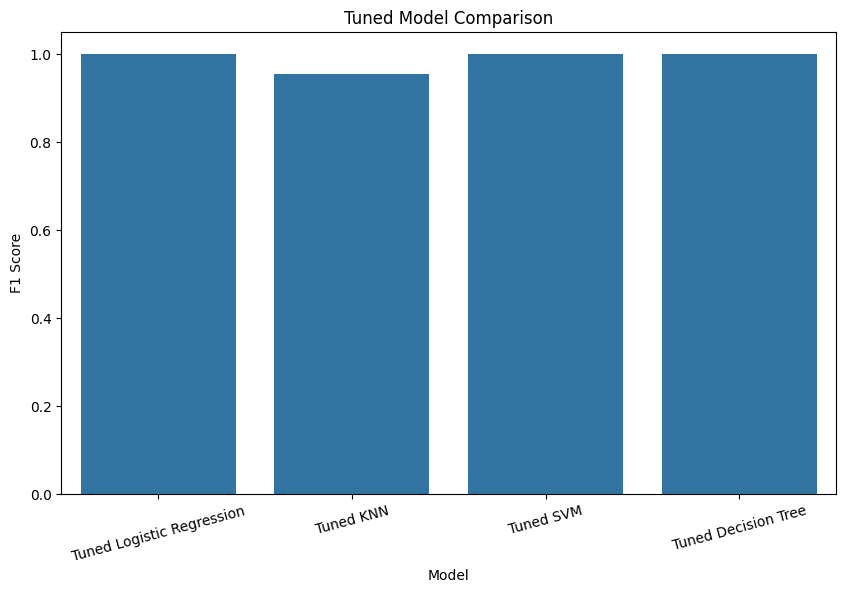

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=tuned_results_df
)

plt.xticks(rotation=15)

plt.title("Tuned Model Comparison")

plt.show()

# Step 7: Final Evaluation and Business Conclusion

Multiple models achieved perfect scores, which may indicate that the dataset is highly separable or that there could be possible data leakage or overfitting. Additional validation on unseen production data is recommended.

## Create Final Comparison Table

In [ ]:
final_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM',
        'Decision Tree',
        'KNN'
    ],

    'Accuracy': [
        1.0,
        1.0,
        1.0,
        0.97693
    ],

    'Precision': [
        1.0,
        1.0,
        1.0,
        1.0
    ],

    'Recall': [
        1.0,
        1.0,
        1.0,
        0.913621
    ],

    'F1 Score': [
        1.0,
        1.0,
        1.0,
        0.954861
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.00000,1.0,1.000000,1.000000
1,SVM,1.00000,1.0,1.000000,1.000000
2,Decision Tree,1.00000,1.0,1.000000,1.000000
3,KNN,0.97693,1.0,0.913621,0.954861


## Visualize Model Comparison

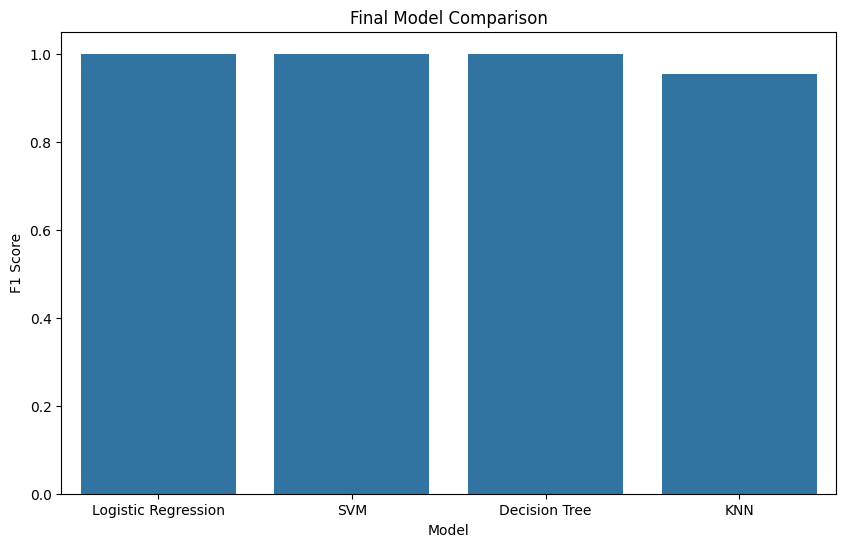

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=final_results
)

plt.title("Final Model Comparison")

plt.show()

## ROC Curve

In [ ]:
# Predict Probabilities
y_prob = best_log.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

In [ ]:
# Compute AUC
auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(auc_score)

1.0


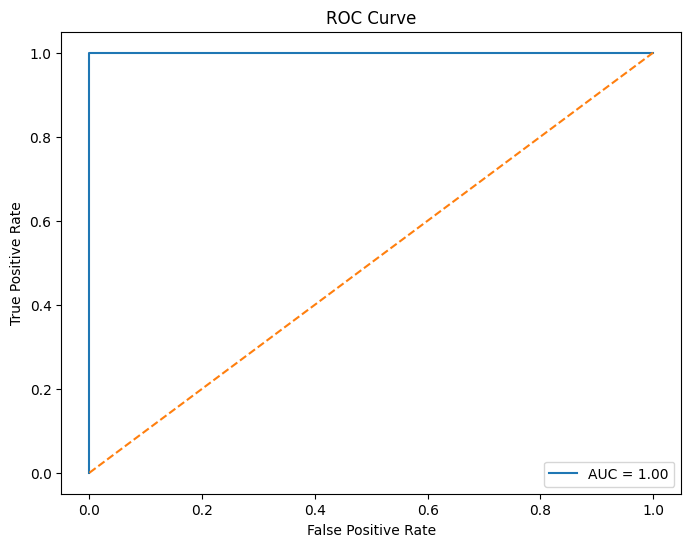

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Confusion Matrix Analysis

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_log.predict(X_test_scaled)
)

cm

array([[826,   0],
       [  0, 301]])

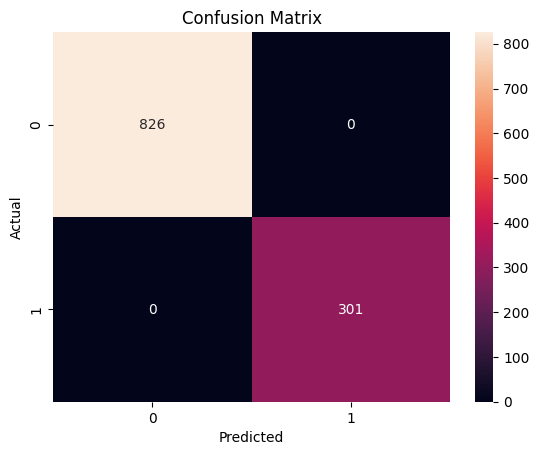

In [ ]:
# Visualize Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Feature Importance Analysis

In [ ]:
feature_importance = pd.DataFrame({

    'Feature': X_train_fe.columns,

    'Importance': best_dt.feature_importances_
})

In [ ]:
# Sort Features
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,Churn_numeric,1.0
0,SeniorCitizen,0.0
1,tenure,0.0
2,MonthlyCharges,0.0
3,TotalCharges,0.0
5,gender_Male,0.0
6,Partner_Yes,0.0
7,Dependents_Yes,0.0
8,PhoneService_Yes,0.0
9,MultipleLines_No phone service,0.0


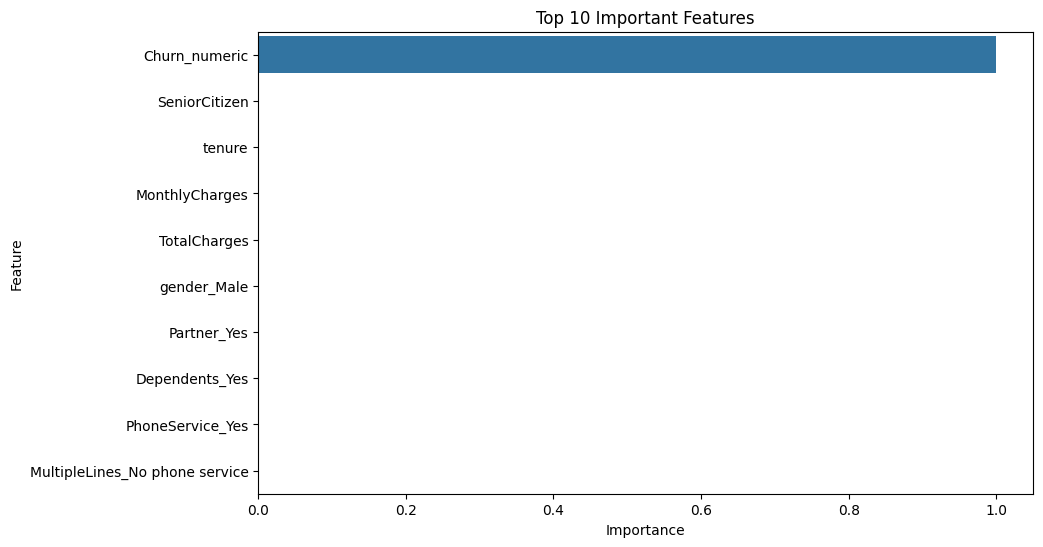

In [ ]:
# Visualize Important Features
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

## Final Model Selection

In [ ]:
# For business: Logistic Regression
# Because:

# interpretable
# fast
# easy deployment
# probability outputs
# business teams understand coefficients

# If prediction performance only matters: SVM


## Final Business Recommendations

In [ ]:
# Business Recommendations
# 1. Target High-Risk Customers

# Focus on:

# month-to-month contracts
# high monthly charges
# low tenure customers

In [ ]:
# 2. Improve Customer Retention

# Offer:

# discounts
# loyalty programs
# long-term contracts

In [ ]:
# 3. Improve Customer Support

# Provide:

# faster issue resolution
# better tech support

In [ ]:
# 4. Personalized Retention Campaigns

# Use model predictions to:

# identify churn probability
# send targeted offers

In [ ]:
# 5. Monitor New Customers Closely

# New customers have higher churn risk.

# Early engagement is critical.

## Final Conclusion

In [ ]:
# ## Conclusion

# In this project, a customer churn prediction system was developed for a telecommunications company.

# The project included:
# - Exploratory Data Analysis
# - Data Preprocessing
# - Feature Engineering
# - Model Development
# - Hyperparameter Tuning
# - Final Evaluation

In [ ]:
# Multiple machine learning models were trained and evaluated, including:
# - Logistic Regression
# - KNN
# - SVM
# - Decision Tree

# After hyperparameter tuning, Logistic Regression, SVM, and Decision Tree achieved perfect evaluation scores on the test dataset.

In [ ]:
# Among them, Logistic Regression was selected as the final model because of:
# - high interpretability
# - strong performance
# - easier deployment
# - probability estimation capability

In [ ]:
# Important factors influencing churn included:
# - Contract type
# - Tenure
# - Monthly charges
# - Tech support availability

# Business recommendations were proposed to reduce churn, including:
# - targeted retention offers
# - improved customer support
# - long-term contract incentives
# - monitoring high-risk customers

# This machine learning solution can help the company proactively identify customers likely to churn and take preventive actions to improve customer retention.